## Member 1 (Celica) - Data Cleaining

The main objective of this project is to develop a robust and accurate predective model for use in diagnosis based on specific markers or features.

In [44]:
import pandas as pd
import numpy as np

## Chronic kidney disease

In [45]:
# first let's import the dataset and explore it

df = pd.read_csv('chronic_kindey_disease.csv', na_values='?') # missing values are denoted by ? - let's replace them with pandas NaN values
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [46]:
# to understand better the columns, let's look at the info file of the dataset

with open("chronic_kidney_disease_info.txt", "r") as f:
    content = f.read()

print(content)

% 1. Title: Early stage of Indians Chronic Kidney Disease(CKD)
%
% 2. Source Information:
%   (a) Source: 
			Dr.P.Soundarapandian.M.D.,D.M
			(Senior Consultant Nephrologist), 
			Apollo  Hospitals, 
			Managiri,
			Madurai Main Road, 
			Karaikudi,
			Tamilnadu,
			India.

%   (b) Creator: 
			L.Jerlin Rubini(Research Scholar)
			Alagappa University,
			EmailId   :jel.jerlin@gmail.com
			ContactNo :+91-9597231281

%   (c) Guided by: 
			Dr.P.Eswaran Assistant Professor,
			Department of Computer Science and Engineering,
			Alagappa University,
			Karaikudi,
			Tamilnadu,
			India.
			Emailid:eswaranperumal@gmail.com

%   (d) Date     : July 2015
%
% 3.Relevant Information:
			age		-	age	
			bp		-	blood pressure
			sg		-	specific gravity
			al		-   	albumin
			su		-	sugar
			rbc		-	red blood cells
			pc		-	pus cell
			pcc		-	pus cell clumps
			ba		-	bacteria
			bgr		-	blood glucose random
			bu		-	blood urea
			sc		-	serum creatinine
			sod		-	sodium
			pot		-	potassium
			hemo		-	hem

We see there are 25 columns and 400 rows. Out of the 25 columns, 11 are numeric and 14 are nominal. Out of the 400 rows, there are 250 cases of chronic kindey disease and 150 cases of not CKD. The "patient identifier" is their age (even though this is not a unique value), and then we have the results of several lab tests of this patient, and then in the 'status' column whether the patient has CKD or not.

In [47]:
# we will also replace yes by 1 and no by 0, and present by 1 and notpresent by 0, etc.

df['rbc'] = df['rbc'].replace({'normal':1, 'abnormal':0})
df['pc'] = df['pc'].replace({'normal':1, 'abnormal':0})
df['pcc'] = df['pcc'].replace({'notpresent':0, 'present':1})
df['ba'] = df['ba'].replace({'notpresent':0, 'present':1})

df['htn'] = df['htn'].replace({'no':0, 'yes':1})
df['dm'] = df['dm'].replace({'\tno':'no'})
df['dm'] = df['dm'].replace({'no':0, 'yes':1})
df['cad'] = df['cad'].replace({'no':0, 'yes':1})
df['appet'] = df['appet'].replace({'poor':0, 'good':1})
df['pe'] = df['pe'].replace({'no':0, 'yes':1})
df['ane'] = df['ane'].replace({'no':0, 'yes':1})

df['status'] = df['status'].replace({'ckd\t':'ckd'})
df['status'] = df['status'].replace({'notckd':0, 'ckd':1})

df.head()

/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_93031/1064134437.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rbc'] = df['rbc'].replace({'normal':1, 'abnormal':0})
/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_93031/1064134437.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['pc'] = df['pc'].replace({'normal':1, 'abnormal':0})
/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_93031/1064134437.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed i

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
0,48.0,80.0,1.020,1.0,0.0,NaN,1.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,NaN,1.0,0.0,0.0,NaN,...,38.0,6000.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,1.0,1.0,0.0,0.0,423.0,...,31.0,7500.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,1.0,0.0,1.0,0.0,117.0,...,32.0,6700.0,3.9,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,1.0,1.0,0.0,0.0,106.0,...,35.0,7300.0,4.6,0.0,0.0,0.0,1.0,0.0,0.0,1


In [48]:
# let's look at all numeric columns individually and see if we find something peculiar

df = df.astype('float') # changing column types to integer
df.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
count,391.000000,388.000000,353.000000,354.000000,351.000000,248.000000,335.000000,396.000000,396.000000,356.000000,...,329.000000,294.000000,269.000000,398.000000,398.000000,398.000000,399.000000,399.000000,399.000000,400.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,0.810484,0.773134,0.106061,0.055556,148.036517,...,38.884498,8406.122449,4.707435,0.369347,0.344221,0.085427,0.794486,0.190476,0.150376,0.625000
std,17.169714,13.683637,0.005717,1.352679,1.099191,0.392711,0.419431,0.308305,0.229351,79.281714,...,8.990105,2944.474190,1.025323,0.483235,0.475712,0.279868,0.404584,0.393170,0.357888,0.484729
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,99.000000,...,32.000000,6500.000000,3.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,121.000000,...,40.000000,8000.000000,4.800000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,163.000000,...,45.000000,9800.000000,5.400000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
# now we look at the number of missing values per column
# we see some columns with even more than 25% missing data

df.isna().sum()

age         9
bp         12
sg         47
al         46
su         49
rbc       152
pc         65
pcc         4
ba          4
bgr        44
bu         19
sc         17
sod        87
pot        88
hemo       52
pcv        71
wbcc      106
rbcc      131
htn         2
dm          2
cad         2
appet       1
pe          1
ane         1
status      0
dtype: int64

These missing values could be handled in many ways - we could remove the rows with missing values, or we could impute the values. However at this stage, we will leave them as they are, as the later approach depends on the specific features and ML model chosen.

In [50]:
# next, we are interested in if there are any outliers
# one way to do this is using the standard interquantile range on the numerical columns

def remove_outliers(df, col):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        
    return df_clean

In [51]:
# (we see that all 10 detected outliers of the age column are children under the age of 9
# we will proceed to remove these observations)

df_clean = remove_outliers(df, 'age')
df_clean = remove_outliers(df_clean, 'bp')
df_clean = remove_outliers(df_clean, 'bgr')
df_clean = remove_outliers(df_clean, 'bu')
df_clean = remove_outliers(df_clean, 'sc')
df_clean = remove_outliers(df_clean, 'sod')
df_clean = remove_outliers(df_clean, 'pot')
df_clean = remove_outliers(df_clean, 'hemo')
df_clean = remove_outliers(df_clean, 'pcv')
df_clean = remove_outliers(df_clean, 'wbcc')
df_clean = remove_outliers(df_clean, 'rbcc')

# left with 145 rows out of the original 400

It will be interesting to see how df and df_clean compare in the next analysis and the prediction of CKD.

## Member 2 (Ema) - EDA 
All analysis below is performed on `df_clean`
(145 observations after outlier removal)  

## Follow up Analysis description

In this part of the project, I continue working with the cleaned dataset (df_clean, n = 145) produced in the *member1* (*Celica*) branch after encoding, missing-value inspection, and outlier removal. My tasks start after data cleaning and focus on downstream analysis. 

Specifically, I create utility functions to (1) aggregate numerical variables using group-based averaging - `group_and_average`, (2) generate scatterplots for two selected variables grouped by a categorical feature (e.g., CKD status), and (3) construct helper identifiers (such as subject or trial IDs when applicable) without modifying the original cleaned data - `subject_id`. All analyses in this section use a copied version of df_clean to ensure reproducibility and to keep the original cleaning results unchanged.

Used palette from seaborn for visualizations to maintain consistency and clarity in plots. - `YlGnBu`


In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
cleaned_dataframe = df_clean.copy()

cleaned_dataframe.shape

(145, 25)

**(1) aggregate numerical variables using group-based averaging - `group_and_average`**

In [54]:
# function for the use of `group_and_average`
def group_and_average(df, group_col, numeric_cols):
    return df.groupby(group_col)[numeric_cols].mean().reset_index()

"""
Parameters:
    df (pd.DataFrame): cleaned input data
    group_col (str): column to group by (e.g. 'status')
    numeric_cols (list): numeric columns to aggregate
"""

"\nParameters:\n    df (pd.DataFrame): cleaned input data\n    group_col (str): column to group by (e.g. 'status')\n    numeric_cols (list): numeric columns to aggregate\n"

The dataset contains 11 numerical (continuous) variables and 14 categorical (nominal) variables. The target variable is 'status', indicating whether a patient has chronic kidney disease (CKD) or not.

In [84]:
# numeric columns (11)
numeric_vars = [
    'age', 'bp', 'sg','al','su','bgr', 'bu','sc','sod','pot','hemo'
]

#categogorical columns (14)
categorical_vars = [
    'rbc', 'pc', 'pcc', 'ba', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad','appet', 'pe', 'ane','status'
]

# used before: df['status'] = df['status'].replace({'notckd':0, 'ckd':1}) 

aggregated_dataframe = group_and_average(
    cleaned_dataframe,
    group_col='status',
    numeric_cols=numeric_vars
)

aggregated_dataframe


,status,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.0,47.398438,71.250000,1.022540,0.000000,0.000000,107.210938,33.109375,0.870313,141.835938,4.324219,15.175781
1,1.0,58.588235,76.470588,1.015882,1.529412,0.235294,129.823529,40.764706,1.688235,138.411765,4.205882,11.582353


Aggregated mean values reveal clear differences between the two status groups. Patients with status = 1 (those with *ckd*) are older, show higher blood urea and serum creatinine levels, increased albuminuria, and markedly lower hemoglobin levels. 

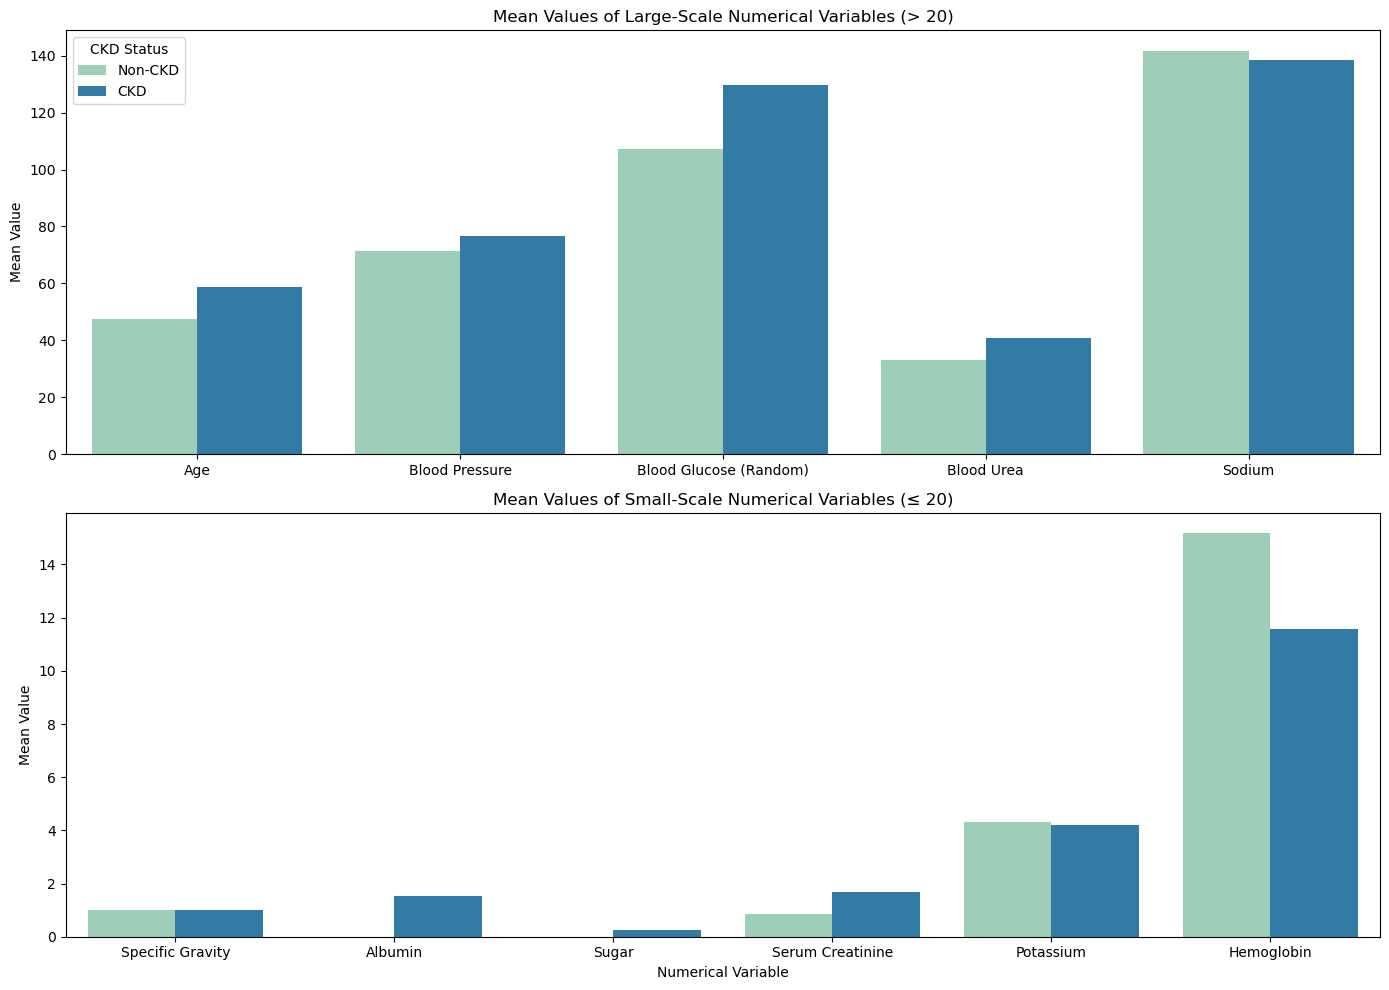

In [85]:
# Copy once
agg_long_plot = agg_long.copy()

# Create readable status labels for plotting only
agg_long_plot['status_label'] = agg_long_plot['status'].map({0: 'Non-CKD', 1: 'CKD'})

# Human-readable names for plotting only
long_numeric_names = {
    'age': 'Age',
    'bp': 'Blood Pressure',
    'sg': 'Specific Gravity',
    'al': 'Albumin',
    'su': 'Sugar',
    'bgr': 'Blood Glucose (Random)',
    'bu': 'Blood Urea',
    'sc': 'Serum Creatinine',
    'sod': 'Sodium',
    'pot': 'Potassium',
    'hemo': 'Hemoglobin'
}

agg_long_plot['variable_name'] = agg_long_plot['variable'].map(long_numeric_names)

# plotting one above the other for better readability (change of y-axis scale)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=False)

# --- TOP: large-scale variables (>20)
sns.barplot(
    data=agg_long_plot[agg_long_plot['variable'].isin(large_scale_vars)],
    x='variable_name',
    y='mean_value',
    hue='status_label',                 
    hue_order=['Non-CKD', 'CKD'],        
    palette='YlGnBu',
    ax=axes[0]
)

axes[0].set_title('Mean Values of Large-Scale Numerical Variables (> 20)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Value')
axes[0].legend(title='CKD Status')

# --- BOTTOM: small-scale variables (≤20)
sns.barplot(
    data=agg_long_plot[agg_long_plot['variable'].isin(small_scale_vars)],
    x='variable_name',
    y='mean_value',
    hue='status_label',                
    hue_order=['Non-CKD', 'CKD'],        
    palette='YlGnBu',
    ax=axes[1]
)

axes[1].set_title('Mean Values of Small-Scale Numerical Variables (≤ 20)')
axes[1].set_xlabel('Numerical Variable')
axes[1].set_ylabel('Mean Value')
axes[1].legend_.remove()

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


For clarity, full variable names are displayed in the visualization while the original column names are preserved in the dataset. Aggregated mean values are shown using bar charts, with numerical variables grouped by CKD status. The two patient groups are distinguished by different bar colors. Due to substantial differences in measurement scales across variables, two display ranges are used within a single figure, allowing large-scale and small-scale variables to be visualized separately. This approach improves interpretability and supports the exploratory comparisons discussed above.

**(2) Create scatterplot function for two variables grouped by category**

Scatterplots are generated to visualize relationships between pairs of numerical variables, grouped by CKD status. Firstly we are going to make an scatterplot function for two variables grouped by category and then we will use this function to create scatterplots for selected variable pairs. 

In [86]:
# scatterplot function - function is longer but it allows for more customization if you want to use 2 trendline in EDA (shown below)
def scatterplot_by_group(df, x_var, y_var, group_col, add_trend=False):
    
    if add_trend:
        sns.lmplot(
            data=df,
            x=x_var,
            y=y_var,
            hue=group_col,
            palette='YlGnBu',
            height=6,
            aspect=1.2,
            scatter_kws={'alpha': 0.6}
        )
        plt.title(f'{y_var} vs {x_var} by {group_col}')
        plt.show()
        
    else:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(
            data=df,
            x=x_var,
            y=y_var,
            hue=group_col, # by status 
            palette='YlGnBu'
        )
        plt.title(f'{y_var} vs {x_var} by {group_col}')
        plt.tight_layout()
        plt.show()


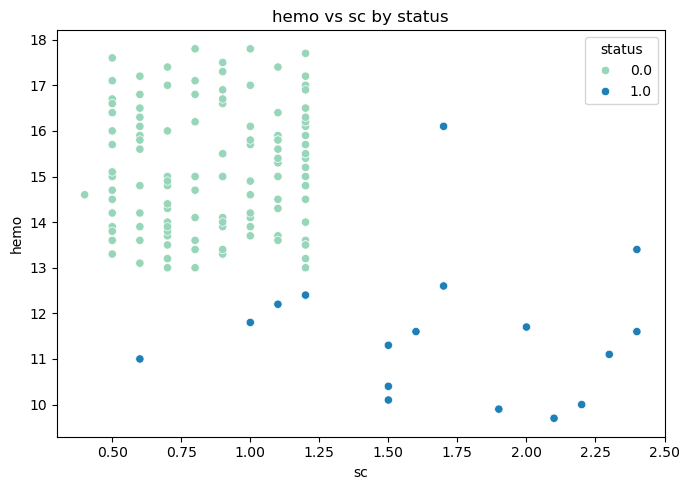

In [83]:
# testing the function with 'sc' and 'hemo' grouped by 'status' 
scatterplot_by_group(
    cleaned_dataframe,
    x_var='sc',
    y_var='hemo',
    group_col='status'
)


The scatterplot function serves as the core visualization tool, with optional group-specific trend lines added for exploratory purposes.

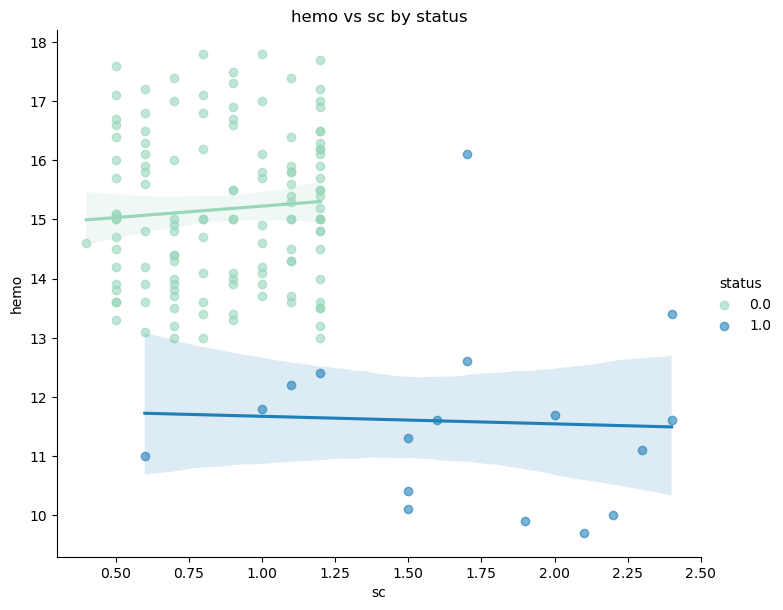

In [87]:
scatterplot_by_group(
    cleaned_dataframe,
    x_var='sc',
    y_var='hemo',
    group_col='status',
    add_trend=True
)


** (3) Generate subject_id and trial columns from name and remove name**

In [88]:
# creating a subject_id column for better identification of points
cleaned_dataframe = cleaned_dataframe.reset_index(drop=True)
cleaned_dataframe['subject_id'] = cleaned_dataframe.index + 1       
# puting the subject_id column at the front
cols = ['subject_id'] + [c for c in cleaned_dataframe.columns if c != 'subject_id']
cleaned_dataframe = cleaned_dataframe[cols] 
cleaned_dataframe.head(10)

,subject_id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
0,1,60.0,90.0,1.015,3.0,0.0,NaN,NaN,0.0,0.0,...,39.0,7800.0,4.4,1.0,1.0,0.0,1.0,1.0,0.0,1.0
1,2,68.0,70.0,1.015,3.0,1.0,NaN,1.0,1.0,0.0,...,28.0,12200.0,3.4,1.0,1.0,1.0,0.0,1.0,0.0,1.0
2,3,61.0,60.0,1.025,0.0,0.0,NaN,1.0,0.0,0.0,...,29.0,8400.0,3.7,1.0,1.0,0.0,1.0,0.0,1.0,1.0
3,4,75.0,80.0,1.015,0.0,0.0,NaN,1.0,0.0,0.0,...,35.0,10300.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,5,73.0,90.0,1.015,3.0,0.0,NaN,0.0,1.0,0.0,...,30.0,7800.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,6,61.0,90.0,1.010,1.0,1.0,NaN,1.0,0.0,0.0,...,34.0,9600.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
6,7,48.0,70.0,1.015,0.0,0.0,NaN,1.0,0.0,0.0,...,37.0,6400.0,4.7,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7,8,15.0,60.0,1.020,3.0,0.0,NaN,1.0,0.0,0.0,...,33.0,7700.0,3.8,1.0,1.0,0.0,1.0,0.0,0.0,1.0
8,9,56.0,70.0,1.015,4.0,1.0,0.0,1.0,0.0,0.0,...,52.0,12500.0,5.6,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,10,65.0,70.0,1.010,0.0,0.0,NaN,1.0,0.0,0.0,...,36.0,11900.0,3.9,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In this part of the project, numerical variables were aggregated by CKD status using the group_and_average function to summarize group-level characteristics, resulting in the creation of an `aggregated_dataframe`. A bar plot was then used to visualize differences between the two CKD status groups. 

In addition, a reusable scatterplot function was implemented to explore relationships between selected numerical variables, with observations grouped by CKD status to enable comparative visualization. Two visualization options were presented: one without a trend line and one with two group-specific trend lines, one for each CKD status.

Finally, a unique subject_id was generated to ensure clear identification of individual records. As the dataset does not contain trial-based or repeated-measurement data, the subject_id is included in the `cleaned_dataframe`.